In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

In [4]:
claims = pd.read_csv('cleaned_data.csv')
print("Dataset loaded successfully!")
print(claims.shape)
print(claims.head())

Dataset loaded successfully!
(558211, 51)
   Provider  InscClaimAmtReimbursed  AttendingPhysician  OperatingPhysician  \
0      3928                   26000               53275               35315   
1      3923                    5000                4951                2132   
2      4034                    5000               40843               35315   
3      1125                    5000               39020               23575   
4      4490                   10000               45475               25118   

   OtherPhysician  ClmAdmitDiagnosisCode  DeductibleAmtPaid  \
0           46457                   3022             1068.0   
1           46457                   2298             1068.0   
2            5201                    851             1068.0   
3           14717                   1602             1068.0   
4           46457                   2976             1068.0   

   DiagnosisGroupCode  ClmDiagnosisCode_1  ClmDiagnosisCode_2  ...  \
0                 154             

In [5]:
X = claims.drop('PotentialFraud', axis=1)
y = claims['PotentialFraud']

print("Input shape:", X.shape)
print("Output shape:", y.shape)
print("Fraud distribution:")
print(y.value_counts())

Input shape: (558211, 50)
Output shape: (558211,)
Fraud distribution:
PotentialFraud
0    345415
1    212796
Name: count, dtype: int64


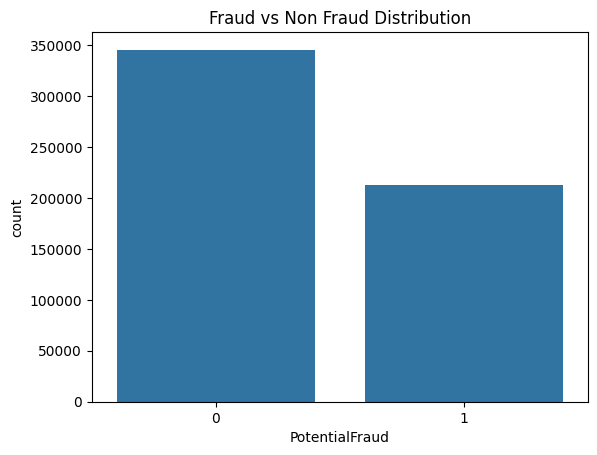

Fraud percentage: 38.12 %
Non Fraud percentage: 61.88 %


In [6]:
sns.countplot(x=y)
plt.title('Fraud vs Non Fraud Distribution')
plt.show()

print("Fraud percentage:", round(y.mean() * 100, 2), "%")
print("Non Fraud percentage:", round((1 - y.mean()) * 100, 2), "%")

In [7]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Check missing values in X
print("Missing values in X before SMOTE:")
print(X.isnull().sum().sum())

# Fill any remaining missing values
X = X.fillna(0)

# Verify no missing values
print("Missing values after filling:")
print(X.isnull().sum().sum())

Missing values in X before SMOTE:
517737
Missing values after filling:
0


In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print("After SMOTE:")
print(pd.Series(y).value_counts())

After SMOTE:
PotentialFraud
1    345415
0    345415
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (552664, 50)
Testing size: (138166, 50)


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


In [25]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")
print(classification_report(y_test, rf_pred))

Random Forest Results:
Accuracy: 83.73 %
              precision    recall  f1-score   support

           0       0.82      0.86      0.84     69096
           1       0.85      0.81      0.83     69070

    accuracy                           0.84    138166
   macro avg       0.84      0.84      0.84    138166
weighted avg       0.84      0.84      0.84    138166



In [23]:

xgb_model = XGBClassifier(n_estimators=200, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Results:")
print("Accuracy:", round(accuracy_score(y_test, xgb_pred) * 100, 2), "%")
print(classification_report(y_test, xgb_pred))

XGBoost Results:
Accuracy: 90.28 %
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     69096
           1       0.92      0.88      0.90     69070

    accuracy                           0.90    138166
   macro avg       0.90      0.90      0.90    138166
weighted avg       0.90      0.90      0.90    138166



           Model  Accuracy
0  Random Forest     83.73
1        XGBoost     90.28


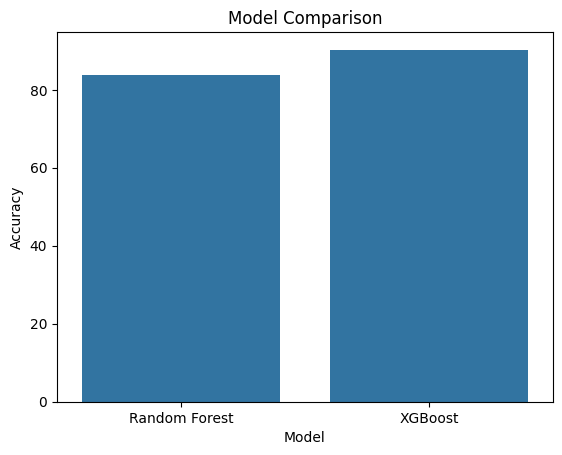

In [26]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        round(accuracy_score(y_test, rf_pred) * 100, 2),
        round(accuracy_score(y_test, xgb_pred) * 100, 2)
    ]
})

print(results)

sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Comparison')
plt.show()

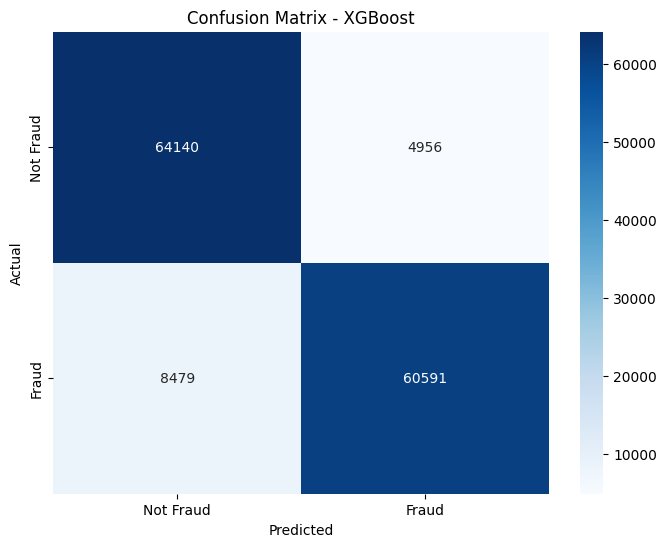

In [27]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

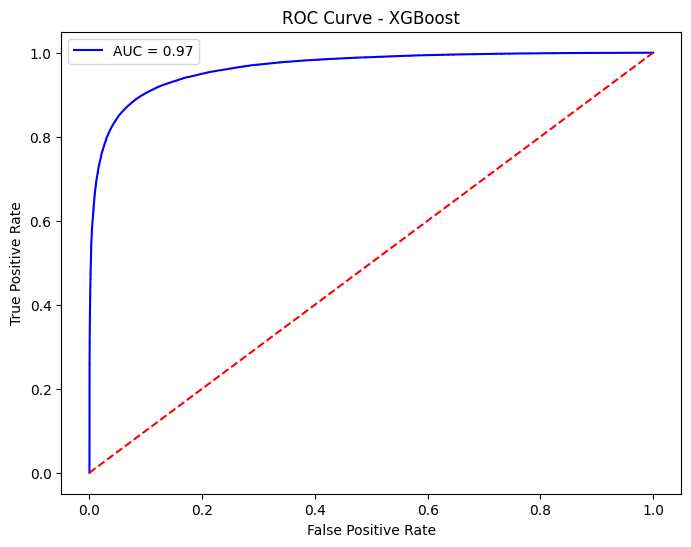

AUC Score: 0.97


In [28]:
fpr, tpr, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve - XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print("AUC Score:", round(roc_auc, 2))

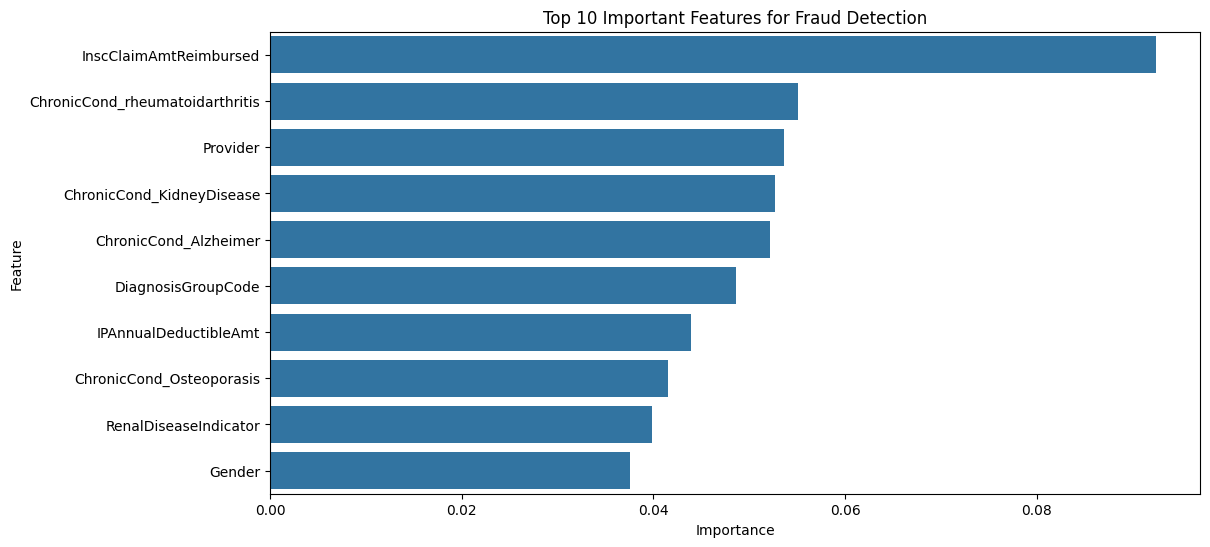

In [17]:
feature_importance = pd.DataFrame({
    'Feature': claims.drop('PotentialFraud', axis=1).columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Top 10 Important Features for Fraud Detection')
plt.show()

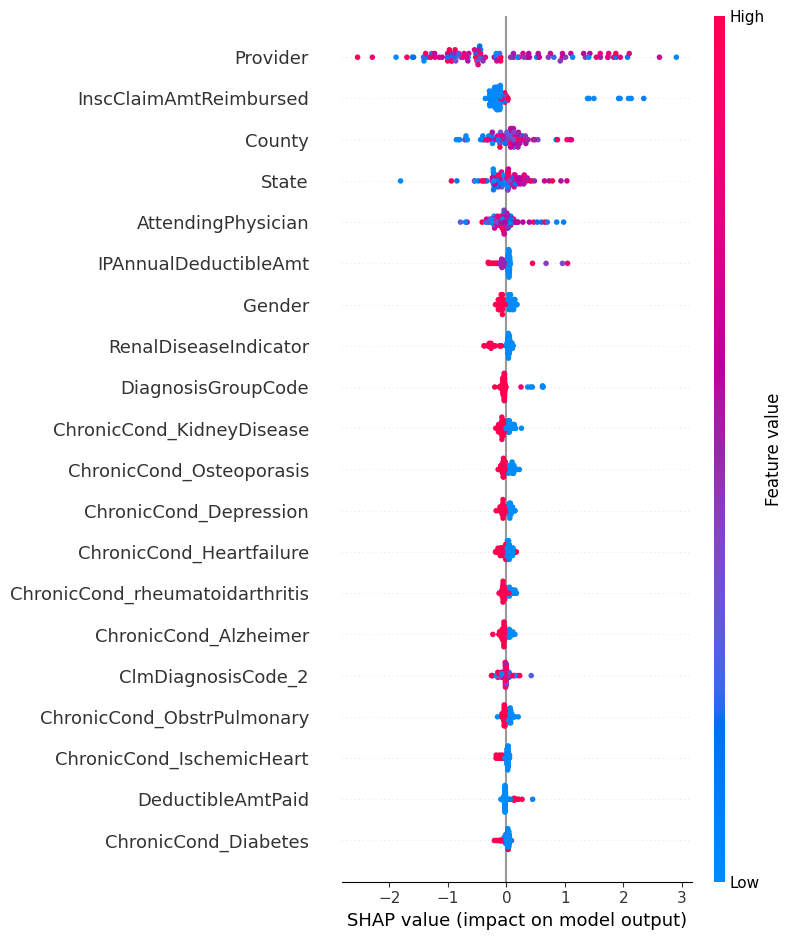

In [18]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:100])

shap.summary_plot(shap_values, X_test[:100],
                  feature_names=claims.drop('PotentialFraud', axis=1).columns)

In [19]:
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
